# Proyecto AgroTech: Entrenamiento y Evaluación de Modelos

Este notebook realiza el entrenamiento del modelo **XGBoost** para predecir condiciones climáticas, aplicando técnicas de balanceo de datos para mejorar la detección de eventos climáticos poco frecuentes (lluvia, tormentas, nieve).

## Importar librerias

In [2]:
# 1. Instalación de librerías necesarias
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn rich ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import os
import glob
import time
import random
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from joblib import dump
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

warnings.filterwarnings('ignore')
console = Console()

## Cargar datos

In [5]:
def load_data_from_folders(base_dir):
    all_data = []
    file_paths = glob.glob(os.path.join(base_dir, "*", "data.csv"))
    if not file_paths:
        return pd.DataFrame()
    for path in file_paths:
        df = pd.read_csv(path)
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

# Cargar datos preprocesados
train_df = load_data_from_folders("/content/drive/MyDrive/IAA/train")
test_df = load_data_from_folders("/content/drive/MyDrive/IAA/test")

print(f"Registros de entrenamiento: {len(train_df)}")
print(f"Registros de test: {len(test_df)}")

Registros de entrenamiento: 24544
Registros de test: 10520


In [6]:
train_df.head()

,date,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,shortwave_radiation,apparent_temperature,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition,VPD,water_balance,heat_stress_duration
0,2022-01-02 06:00:00+00:00,-0.008335,0.230053,-0.168132,-0.168017,0.463250,-0.701083,-0.233959,-0.580492,0.0,-0.351188,-0.687798,0.084017,-0.695376,0.499434,-0.926986,Cloudy,-0.351230,0.071442,-0.268822
1,2022-01-02 07:00:00+00:00,0.025147,0.177726,-0.168132,-0.168017,0.748931,-0.431344,-0.164376,-0.680239,0.0,-0.318295,-0.687798,0.093050,-0.669619,0.433360,-0.926986,Cloudy,-0.318349,0.063142,-0.268822
2,2022-01-02 15:00:00+00:00,1.297456,-1.496939,-0.168132,-0.168017,0.507201,-0.877198,-0.233959,-0.131633,1.0,1.543412,2.194241,1.499724,2.097992,1.346393,-0.934676,Cloudy,1.543606,-0.828753,-0.268822
3,2022-01-02 16:00:00+00:00,1.558615,-1.820500,-0.168132,-0.168017,0.661029,-0.715900,-0.233959,-0.206443,1.0,2.149846,2.551653,1.758249,2.569287,1.658747,-0.934676,Cloudy,2.150129,-0.980633,-0.268822
4,2022-01-04 09:00:00+00:00,0.065325,0.857061,-0.168132,-0.168017,1.144489,0.942656,-0.164376,-0.405936,0.0,-0.639789,-0.687798,0.144348,-0.696220,0.499434,-0.926986,Cloudy,-0.639562,0.071714,-0.268822


In [7]:
for i in range(len(train_df.columns)):
    print(train_df.columns[i])

date
temperature_2m
relative_humidity_2m
precipitation
rain
cloud_cover
wind_speed_10m
weather_code
pressure_msl
is_day
vapour_pressure_deficit
shortwave_radiation
apparent_temperature
et0_fao_evapotranspiration
soil_temperature_0_to_7cm
soil_moisture_0_to_7cm
weather_condition
VPD
water_balance
heat_stress_duration


In [8]:
train_df.describe(include='all').round(1)

,date,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,shortwave_radiation,apparent_temperature,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition,VPD,water_balance,heat_stress_duration
count,24544,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544.0,24544,24544.0,24544.0,24544.0
unique,24544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN
top,2024-10-10 22:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sunny,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12246,NaN,NaN,NaN
mean,NaN,-0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.5,-0.0,-0.0,-0.1,-0.0,-0.0,0.2,NaN,-0.0,0.0,-0.0
std,NaN,1.0,1.0,1.1,1.1,1.0,1.0,1.1,1.0,0.5,1.0,1.0,1.0,1.0,1.0,0.9,NaN,1.0,1.1,1.0
min,NaN,-2.7,-2.7,-0.2,-0.2,-1.1,-1.8,-0.4,-3.5,0.0,-0.8,-0.7,-2.7,-0.7,-2.5,-1.0,NaN,-0.8,-1.4,-0.3
25%,NaN,-0.8,-0.6,-0.2,-0.2,-1.1,-0.7,-0.4,-0.7,0.0,-0.7,-0.7,-0.8,-0.7,-0.8,-0.8,NaN,-0.7,-0.2,-0.3
50%,NaN,-0.2,0.3,-0.2,-0.2,0.0,-0.1,-0.2,-0.1,0.0,-0.4,-0.7,-0.2,-0.5,-0.3,0.3,NaN,-0.4,0.0,-0.3
75%,NaN,0.5,0.9,-0.2,-0.2,1.1,0.6,-0.2,0.7,1.0,0.2,0.4,0.5,0.2,0.6,1.0,NaN,0.2,0.1,-0.3


## Visualización de variables

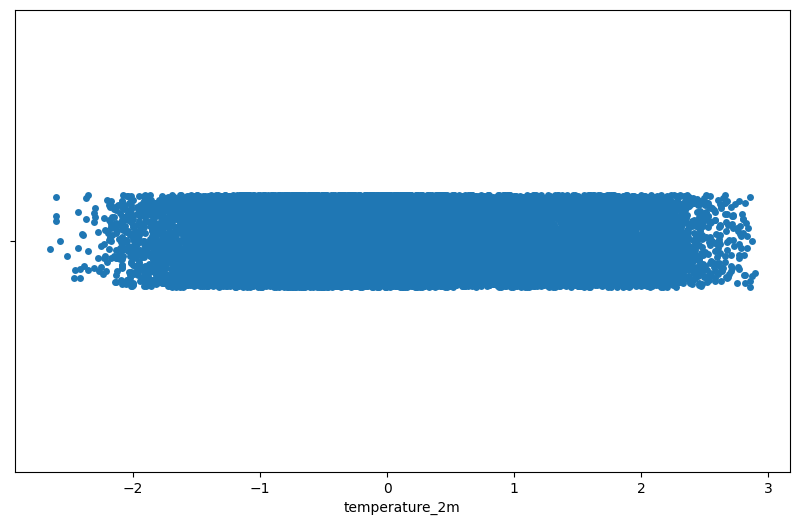

Porcentaje de NaN en temperature_2m: 0.00%


In [9]:
var_check = 'temperature_2m'
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=train_df)
plt.xlabel(var_check)
plt.show()
train_df.loc[train_df[var_check] > 1500, [var_check]] = np.nan
nan_percentage = train_df[var_check].isna().sum() / len(train_df) * 100
print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")

Porcentaje de NaN en temperature_2m: 0.00%
Porcentaje de NaN en relative_humidity_2m: 0.00%
Porcentaje de NaN en precipitation: 0.00%
Porcentaje de NaN en rain: 0.00%
Porcentaje de NaN en cloud_cover: 0.00%
Porcentaje de NaN en wind_speed_10m: 0.00%
Porcentaje de NaN en weather_code: 0.00%
Porcentaje de NaN en pressure_msl: 0.00%
Porcentaje de NaN en is_day: 0.00%
Porcentaje de NaN en vapour_pressure_deficit: 0.00%
Porcentaje de NaN en shortwave_radiation: 0.00%
Porcentaje de NaN en apparent_temperature: 0.00%
Porcentaje de NaN en et0_fao_evapotranspiration: 0.00%
Porcentaje de NaN en soil_temperature_0_to_7cm: 0.00%
Porcentaje de NaN en soil_moisture_0_to_7cm: 0.00%
Porcentaje de NaN en VPD: 0.00%
Porcentaje de NaN en water_balance: 0.00%
Porcentaje de NaN en heat_stress_duration: 0.00%


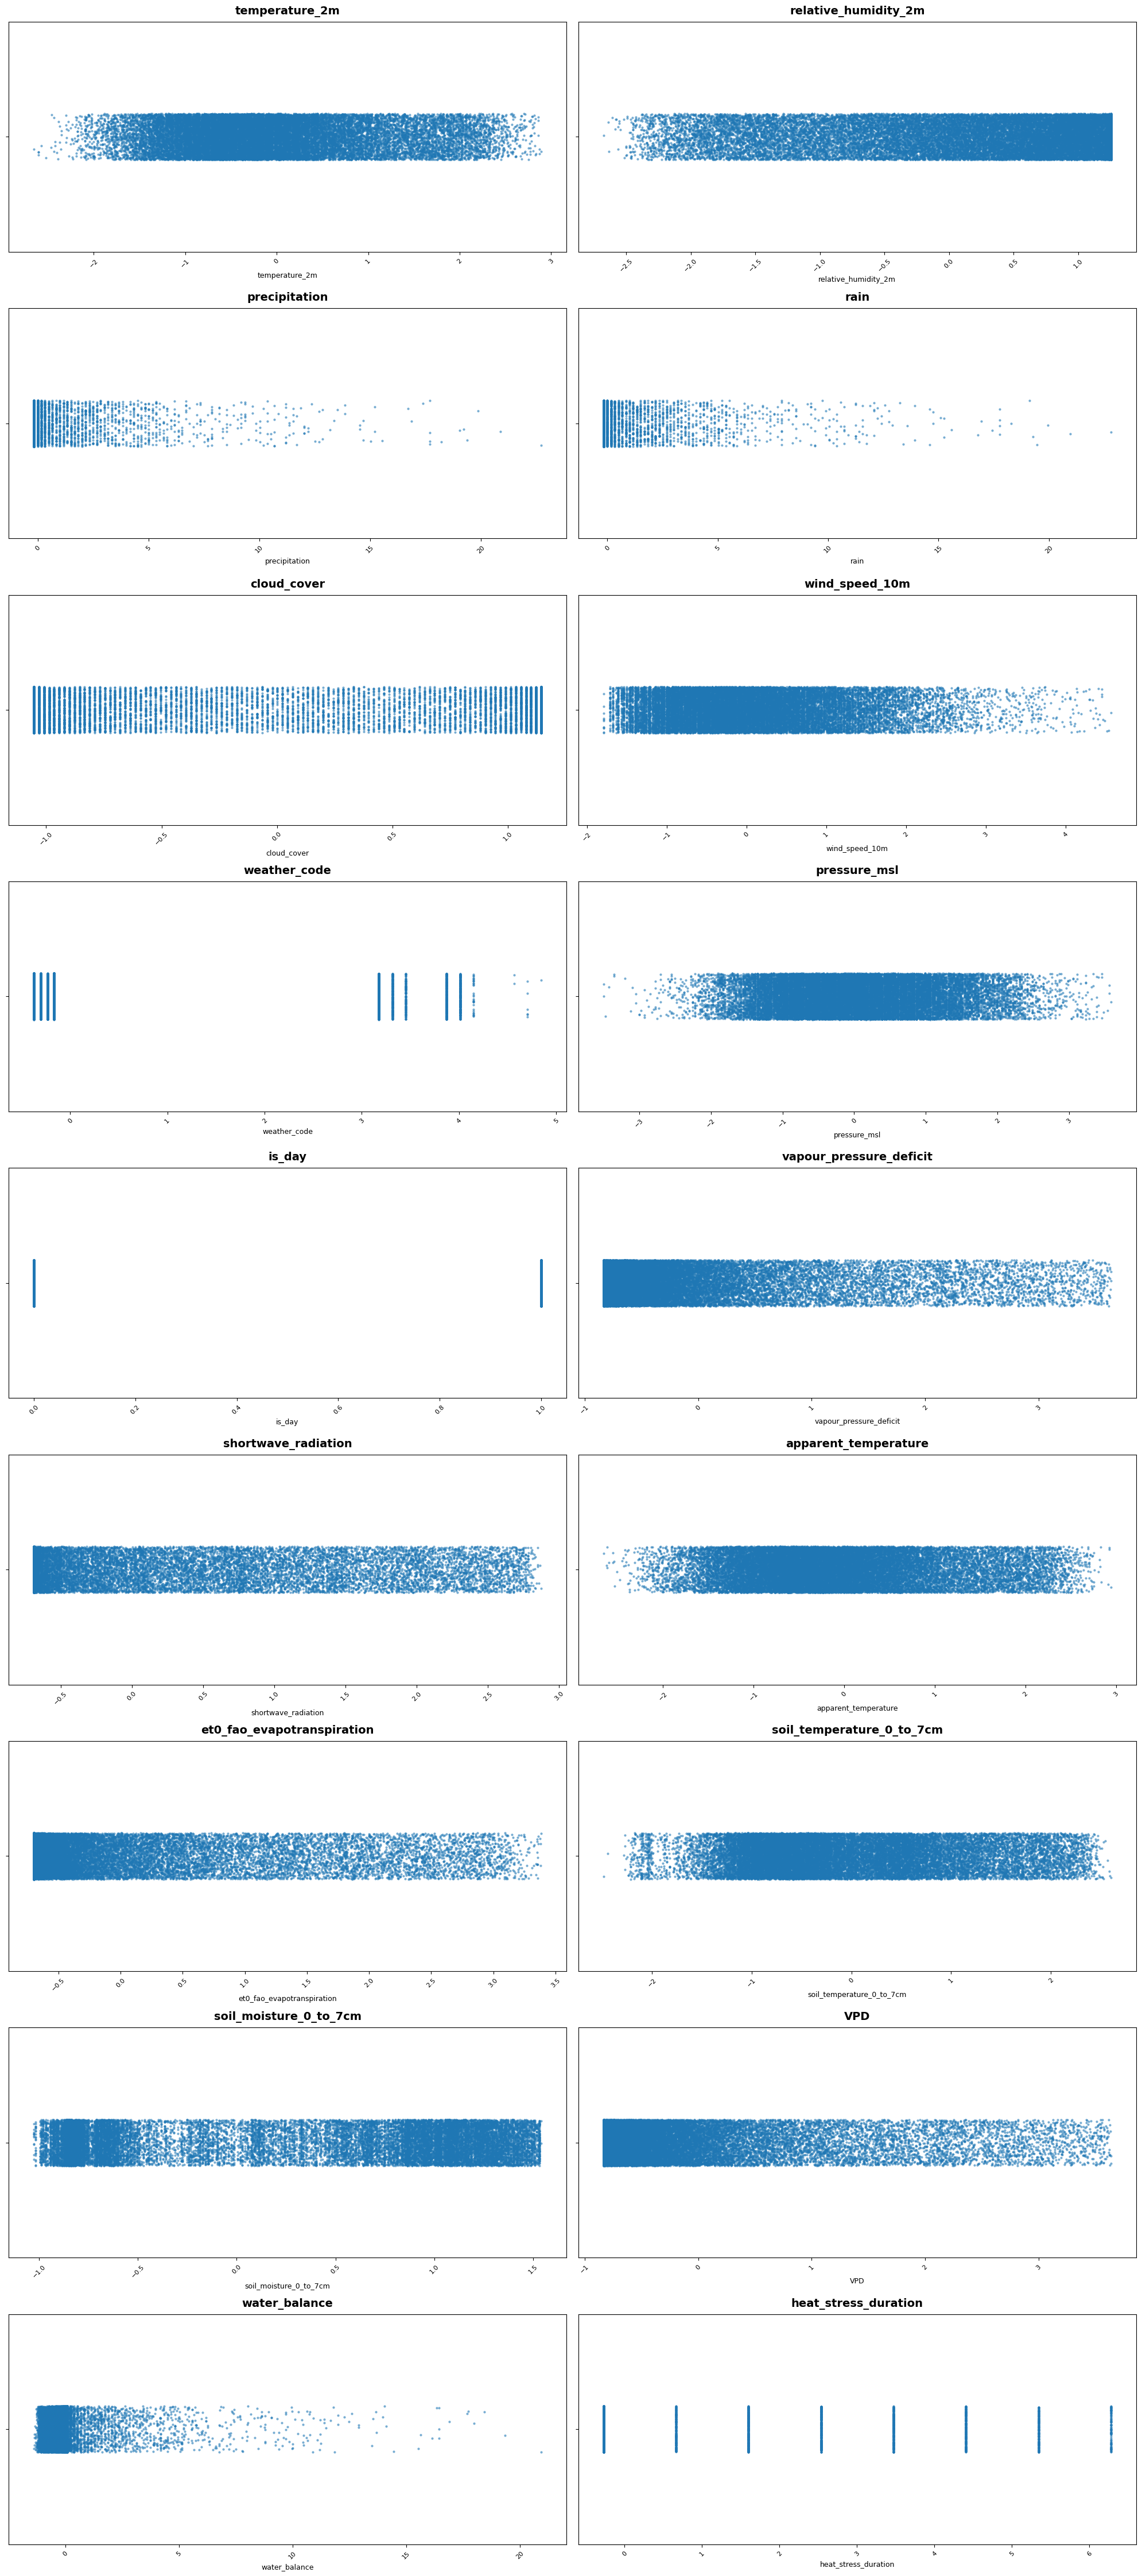

In [10]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
# Configurar grilla
ncols = 2
nrows = (len(numeric_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
axes = axes.flatten()

for idx, var_check in enumerate(numeric_cols):
    ax = axes[idx]
    ax.set_title(var_check, fontsize=14, fontweight='semibold', pad=10)

    sns.stripplot(x=var_check, data=train_df, ax=ax, alpha=0.6, size=3)
    ax.set_xlabel(var_check, fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    train_df.loc[train_df[var_check] > 1500, var_check] = np.nan
    nan_percentage = train_df[var_check].isna().sum() / len(train_df) * 100
    print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")
# Ocultar subplots vacíos
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)
plt.tight_layout()
plt.show()

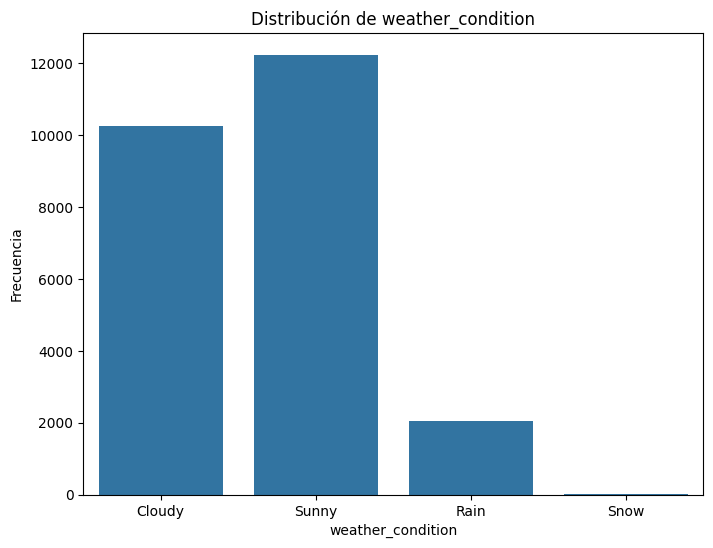

Distribución porcentual:
weather_condition
Sunny     49.894068
Cloudy    41.753585
Rain       8.315678
Snow       0.036669
Name: proportion, dtype: float64


In [11]:
var_check = 'weather_condition'
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=train_df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()
print("Distribución porcentual:")
print(train_df['weather_condition'].value_counts(normalize=True) * 100)

## Selección de Variables (Feature Selection)

Ver con `SelectKBest` las variables que más aportan al modelo, reduciendo la redundancia.

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

X_temp = train_df.drop(columns=['date', 'weather_condition', 'weather_code'])
y_temp = LabelEncoder().fit_transform(train_df['weather_condition'])

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_temp, y_temp)

scores = pd.DataFrame({'Feature': X_temp.columns, 'Score': selector.scores_})
scores = scores.sort_values(by='Score', ascending=False)
print("Top variables por importancia estadística")
print(scores)

Top variables por importancia estadística
                       Feature          Score
4                  cloud_cover  100172.565127
15               water_balance    4600.947026
2                precipitation    4563.847321
3                         rain    4510.446758
13      soil_moisture_0_to_7cm    3617.184424
12   soil_temperature_0_to_7cm    2496.318183
1         relative_humidity_2m    2395.966350
0               temperature_2m    1724.168262
8      vapour_pressure_deficit    1609.792747
14                         VPD    1609.131397
10        apparent_temperature    1565.486015
11  et0_fao_evapotranspiration     757.432767
6                 pressure_msl     680.195711
9          shortwave_radiation     536.011126
16        heat_stress_duration     393.223583
5               wind_speed_10m     388.264383
7                       is_day       4.743927


## Desbalance de Clases

Antes de entrenar, revisamos cuántos registros tenemos de cada condición climática. Un desbalance extremo (ej: 90% Sunny) hará que el modelo ignore las tormentas.

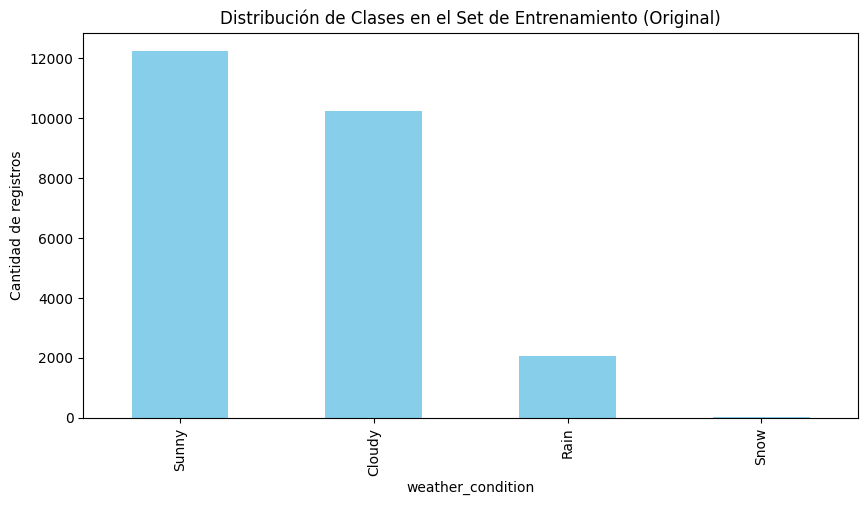

Distribución porcentual:
weather_condition
Sunny     49.894068
Cloudy    41.753585
Rain       8.315678
Snow       0.036669
Name: proportion, dtype: float64


In [13]:
plt.figure(figsize=(10, 5))
train_df['weather_condition'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución de Clases en el Set de Entrenamiento (Original)')
plt.ylabel('Cantidad de registros')
plt.show()

print("Distribución porcentual:")
print(train_df['weather_condition'].value_counts(normalize=True) * 100)

## Técnicas de Balanceo (SMOTE)

Utilizaremos **SMOTE (Synthetic Minority Over-sampling Technique)**. A diferencia del sobremuestreo simple, SMOTE crea nuevos ejemplos sintéticos de las clases minoritarias interpolando entre los existentes.

In [14]:
# Separar Features y Target
X_train = train_df.drop(columns=['date', 'weather_condition', 'weather_code'])
y_train = train_df['weather_condition']

X_test = test_df.drop(columns=['date', 'weather_condition', 'weather_code'])
y_test = test_df['weather_condition']

# Codificar etiquetas
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train_encoded)

print(f"Forma original de y_train: {np.bincount(y_train_encoded)}")
print(f"Nueva forma de y_train (balanceada): {np.bincount(y_train_res)}")

Forma original de y_train: [10248  2041     9 12246]
Nueva forma de y_train (balanceada): [12246 12246 12246 12246]


## Entrenamiento del Modelo

In [15]:
results_list = []
best_accuracy = 0
best_model = None
best_params = None
best_duration = 0

In [16]:
# Definir grilla de hiperparámetros para probar para Random Forest
param_grid = [
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2},
    {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}
]

In [17]:
for i, params in enumerate(param_grid):
    start_t = time.time()
    # Crear y entrenar modelo Random Forest
    current_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **params
    )

    current_model.fit(X_train_res, y_train_res)
    duration = time.time() - start_t

    # Evaluación en test
    y_pred_temp = current_model.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred_temp)

    # Guardar resultados
    res = {
        'Iteración': i + 1,
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'] if 'max_depth' in params else 'None',
        'Accuracy': round(acc, 5),
        'Tiempo (s)': round(duration, 2)
    }
    results_list.append(res)

    print(f"Iteración {i+1}: {params} -> Accuracy: {acc:.4f} ({duration:.2f}s)")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = current_model
        best_params = params
        best_duration = duration

# Asignar el mejor modelo y resultados para la evaluación final
model = best_model
training_time = best_duration
y_pred = model.predict(X_test)
acc = accuracy_score(y_test_encoded, y_pred)

Iteración 1: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Accuracy: 0.9988 (9.62s)
Iteración 2: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2} -> Accuracy: 0.9990 (20.02s)
Iteración 3: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Accuracy: 0.9983 (2.70s)


Mejores parámetros: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}
Modelo: Random Forest Classifier
Accuracy en el conjunto de test: 0.9990
Tiempo de entrenamiento: 20.02 segundos


,Iteración,n_estimators,max_depth,Accuracy,Tiempo (s)
1,2,200,20,0.99905,20.02
0,1,100,10,0.99876,9.62
2,3,50,5,0.99829,2.70


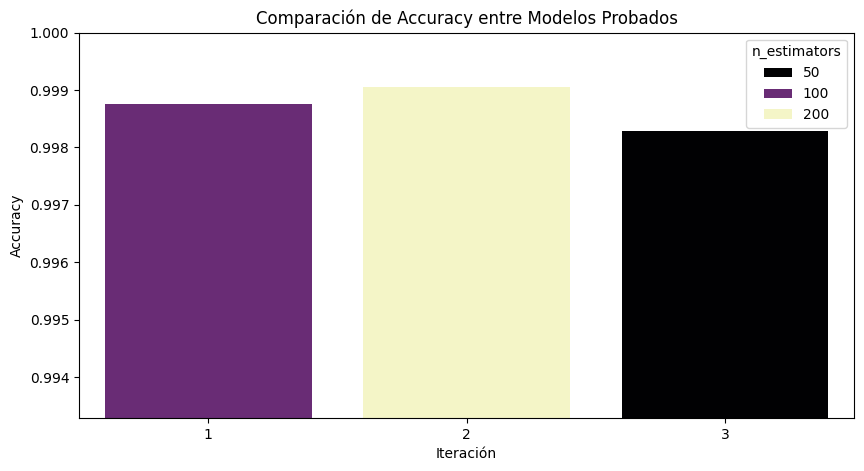

In [18]:
print(f"Mejores parámetros: {best_params}")
print(f"Modelo: Random Forest Classifier")
print(f"Accuracy en el conjunto de test: {accuracy_score(y_test_encoded, y_pred):.4f}")
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")

# Mostrar tabla comparativa
comparison_df = pd.DataFrame(results_list).sort_values(by='Accuracy', ascending=False)
display(comparison_df)

# Graficar comparación de Accuracy
plt.figure(figsize=(10, 5))
sns.barplot(x='Iteración', y='Accuracy', hue='n_estimators', data=comparison_df, palette='magma')
plt.title('Comparación de Accuracy entre Modelos Probados')
plt.ylim(comparison_df['Accuracy'].min() - 0.005, min(1.0, comparison_df['Accuracy'].max() + 0.005))
plt.show()

## Evaluación y Resultados

Classification Report:
              precision    recall  f1-score   support

      Cloudy       1.00      1.00      1.00      3895
        Rain       0.99      0.99      0.99       554
        Snow       0.25      0.12      0.17         8
       Sunny       1.00      1.00      1.00      6063

    accuracy                           1.00     10520
   macro avg       0.81      0.78      0.79     10520
weighted avg       1.00      1.00      1.00     10520



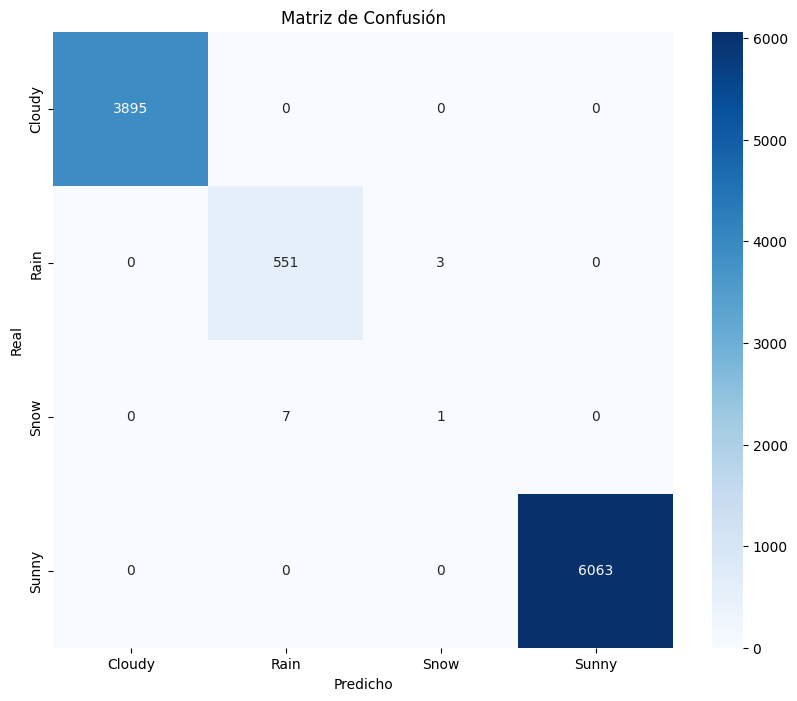

In [19]:
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

# Matriz de Confusión
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## Importancia de las Variables

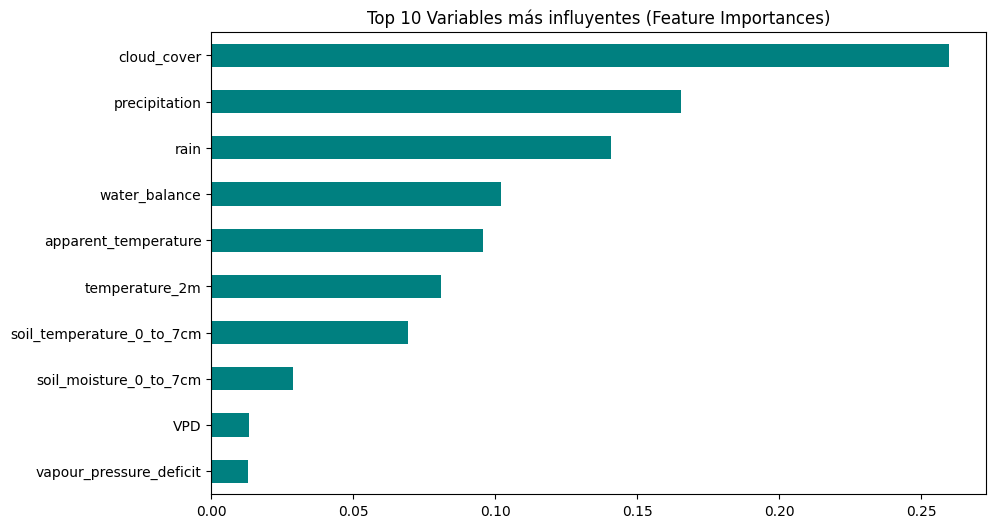

In [20]:
# Para Random Forest, usamos feature_importances_
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Variables más influyentes (Feature Importances)')
plt.show()

## Guardar Modelo y Resumen Final

Guardamos el modelo para su posterior despliegue y mostramos un resumen de los resultados utilizando .

In [21]:
# Guardar el modelo
os.makedirs('outputs', exist_ok=True)
dump(model, 'outputs/random_forest_model.joblib')
dump(le, 'outputs/label_encoder.joblib')
print("Modelo y LabelEncoder guardados en la carpeta 'outputs'.")

# Tabla de resumen
table = Table(title="Resumen de Entrenamiento Random Forest")
table.add_column("Métrica", style="cyan")
table.add_column("Valor")

table.add_row("Precisión (Accuracy)", f"{accuracy_score(y_test_encoded, y_pred):.4f}")
table.add_row("Tiempo de Entrenamiento", f"{training_time:.2f} s")
table.add_row("Registros Train (Balanceados)", str(len(X_train_res)))
table.add_row("Registros Test", str(len(y_test)))

console.print(table)

Modelo y LabelEncoder guardados en la carpeta 'outputs'.


  Resumen de Entrenamiento Random Forest   
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Métrica                       ┃ Valor   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Precisión (Accuracy)          │ 0.9990  │
│ Tiempo de Entrenamiento       │ 20.02 s │
│ Registros Train (Balanceados) │ 48984   │
│ Registros Test                │ 10520   │
└───────────────────────────────┴─────────┘